In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# Dataset
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizatsiya
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Linear regression

Linear Regression
Train R2: 0.6125511913966952
Test R2: 0.5757877060324508
MSE Test: 0.5558915986952444


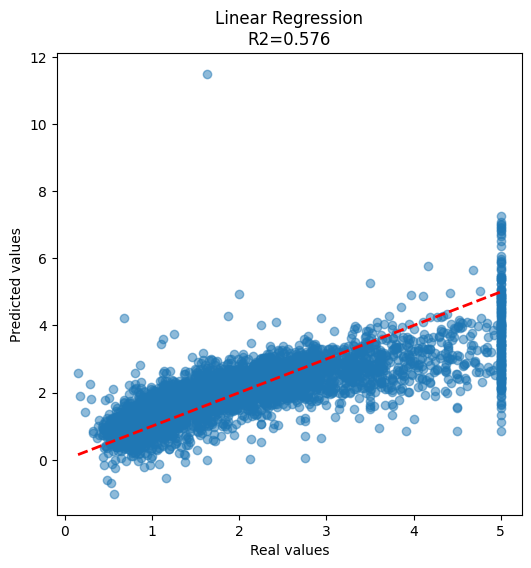

In [3]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

y_pred_train = linreg.predict(X_train_scaled)
y_pred_test = linreg.predict(X_test_scaled)

print("Linear Regression")
print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))
print("MSE Test:", mean_squared_error(y_test, y_pred_test))

# # Koefitsiyentlarni chizma
# plt.figure(figsize=(10,5))
# plt.bar(X.columns, linreg.coef_)
# plt.xticks(rotation=90)
# plt.title("Linear Regression Coefficients")
# plt.show()


plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f"Linear Regression\nR2={r2_score(y_test, y_pred_test):.3f}")
plt.xlabel("Real values")
plt.ylabel("Predicted values")
plt.show()

## Ridge regression

Ridge Regression
Best alpha: 0.001
Test R2: 0.5757877341612515


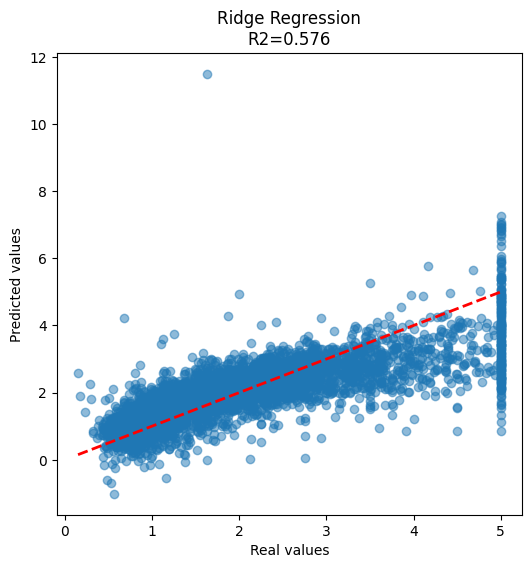

In [6]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge.fit(X_train_scaled, y_train)

y_pred_test = ridge.predict(X_test_scaled)

print("Ridge Regression")
print("Best alpha:", ridge.alpha_)
print("Test R2:", r2_score(y_test, y_pred_test))

# plt.figure(figsize=(10,5))
# plt.bar(X.columns, ridge.coef_)
# plt.xticks(rotation=90)
# plt.title("Ridge Regression Coefficients")
# plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f"Ridge Regression\nR2={r2_score(y_test, y_pred_test):.3f}")
plt.xlabel("Real values")
plt.ylabel("Predicted values")
plt.show()

## Lasso regression

Lasso Regression
Best alpha: 0.001
Test R2: 0.576856256870568
Non-zero Coefs: 8


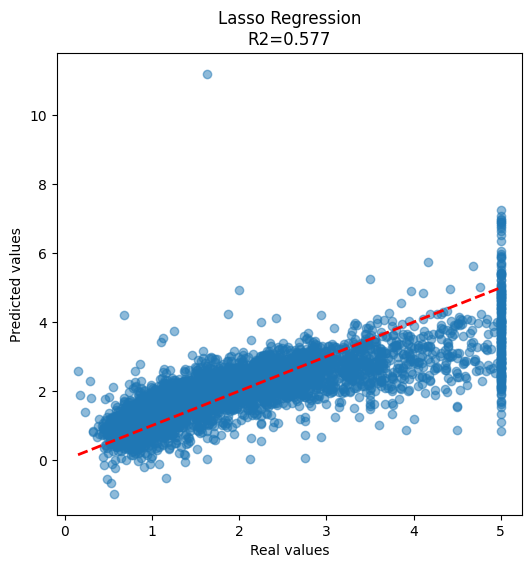

In [7]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(alphas=np.logspace(-3, 1, 50), cv=5, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

y_pred_test = lasso.predict(X_test_scaled)

print("Lasso Regression")
print("Best alpha:", lasso.alpha_)
print("Test R2:", r2_score(y_test, y_pred_test))
print("Non-zero Coefs:", np.sum(lasso.coef_ != 0))

# plt.figure(figsize=(10,5))
# plt.bar(X.columns, lasso.coef_)
# plt.xticks(rotation=90)
# plt.title("Lasso Regression Coefficients")
# plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f"Lasso Regression\nR2={r2_score(y_test, y_pred_test):.3f}")
plt.xlabel("Real values")
plt.ylabel("Predicted values")
plt.show()


## Elasticnet regression

ElasticNet Regression
Best alpha: 0.001
Best l1_ratio: 1.0
Test R2: 0.576856256870568
Non-zero Coefs: 8


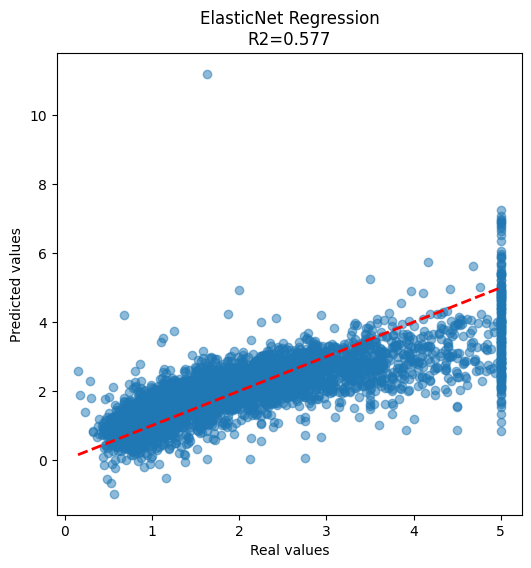

In [ ]:
from sklearn.linear_model import ElasticNetCV

elastic = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1],
                       alphas=np.logspace(-3, 1, 50), cv=5, max_iter=10000)
elastic.fit(X_train_scaled, y_train)

y_pred_test = elastic.predict(X_test_scaled)

print("ElasticNet Regression")
print("Best alpha:", elastic.alpha_)
print("Best l1_ratio:", elastic.l1_ratio_)
print("Test R2:", r2_score(y_test, y_pred_test))
print("Non-zero Coefs:", np.sum(elastic.coef_ != 0))

# plt.figure(figsize=(10,5))
# plt.bar(X.columns, elastic.coef_)
# plt.xticks(rotation=90)
# plt.title("ElasticNet Regression Coefficients")
# plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f"ElasticNet Regression\nR2={r2_score(y_test, y_pred_test):.3f}")
plt.xlabel("Real values")
plt.ylabel("Predicted values")
plt.show()

## **Implementation**

In [9]:
import numpy as np

class LinearRegressionScratch:
    def __init__(self, lr=0.01, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iter):
            y_pred = np.dot(X, self.weights) + self.bias

            dw = -(2/n_samples) * np.dot(X.T, (y - y_pred))
            db = -(2/n_samples) * np.sum(y - y_pred)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


<!-- $2 \cdot (y^{(i)} - \hat{y}^{(i)}) \cdot (-x^{(i)})$ \n -->
$2 \cdot (y^{(i)} - \hat{y}^{(i)}) \cdot (-1)$

In [10]:
class RidgeRegressionScratch:
    def __init__(self, lr=0.01, n_iter=1000, alpha=0.1):
        self.lr = lr
        self.n_iter = n_iter
        self.alpha = alpha
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iter):
            y_pred = np.dot(X, self.weights) + self.bias

            dw = -(2/n_samples) * np.dot(X.T, (y - y_pred)) + 2 * self.alpha * self.weights
            db = -(2/n_samples) * np.sum(y - y_pred)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


In [11]:
class LassoRegressionScratch:
    def __init__(self, lr=0.01, n_iter=1000, alpha=0.1):
        self.lr = lr
        self.n_iter = n_iter
        self.alpha = alpha
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iter):
            y_pred = np.dot(X, self.weights) + self.bias

            dw = -(2/n_samples) * np.dot(X.T, (y - y_pred)) + self.alpha * np.sign(self.weights)
            db = -(2/n_samples) * np.sum(y - y_pred)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


In [ ]:
class ElasticNetScratch:
    def __init__(self, lr=0.01, n_iter=1000, alpha=0.1, l1_ratio=0.5):
        self.lr = lr
        self.n_iter = n_iter
        self.alpha = alpha      # umumiy penalty kuchi
        self.l1_ratio = l1_ratio # L1 vs L2 balansi
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        l1 = self.alpha * self.l1_ratio
        l2 = self.alpha * (1 - self.l1_ratio)

        for _ in range(self.n_iter):
            y_pred = np.dot(X, self.weights) + self.bias

            dw = -(2/n_samples) * np.dot(X.T, (y - y_pred)) + l1 * np.sign(self.weights) + 2 * l2 * self.weights
            db = -(2/n_samples) * np.sum(y - y_pred)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias
